<a href="https://colab.research.google.com/github/Jompy-GitHub/MTS-UncertainEnvironment/blob/main/analisis-resultados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis de Resultados: Pruebas Multiagente

# Configurar el entorno
Ejecutar siempre al principio

In [1]:
# Montar unidad de Drive
from google.colab import drive
import os
import json
import subprocess

drive.mount("/content/drive")
path = "drive/MyDrive/TFG-Yago Broton/Busqueda con incertidumbre/Código/TFG-Yago"
os.chdir(path)
print(os.listdir(os.getcwd()))

Mounted at /content/drive
['.ipynb_checkpoints', 'resultados', 'pruebas', 'graficas', 'graficas-enjambre', 'graficas-indicios', 'analisis-resultados-multiindicio.ipynb', 'lanzar-pruebas.ipynb', 'analisis-resultados-mulitagente.ipynb', 'analisis-resultados.ipynb']


In [2]:
# Importar librerías
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import gaussian_kde

# Para poder exportar las gráficas de plotly a pdf
!pip install -U kaleido
import kaleido

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 7.7 MB/s eta 0:00:00


In [3]:
def process_csv(file_path):
    # Coger el CSV y leer lo que nos interesa para las estadísticas
    # etiquetas, pasos y si se encontró el objetivo
    # Coger 5 filas: 1 (inicial), 2 (final), 3 (dist), 4(pasos/tiempo), 5(found),
    df = pd.read_csv(file_path, header=0, index_col=0 , nrows=5)

    # Sacar la estrategia del nombre del archivo
    strategy = os.path.basename(file_path).split(".")[0].split("-")[:-1]
    strategy = "-".join(strategy)

    # Sacar la información del df
    finder = df.loc["Found Target", "Target"]
    found = not np.isnan(float(finder))
    distance = float(df.loc["Distance", "Agent " + str(finder)]) if found else df.loc["Distance", "Agent 0"]
    steps = float(df.loc["Steps taken", "Agent 0"])
    steps_f = float(df.loc["Steps taken", "Agent " + str(finder)]) if found else None
    agents = str(len(df.columns) - 1)

    # Desplazamiento (Pfinal - Pinicial)
    displacements = []
    # Seleccionar solo las columnas
    agent_columns = [col for col in df.columns if col.startswith("Agent")]
    for agent in agent_columns:
        # La posición es un string de la forma: "[xx yy]"
        # Primero primero hay que quitar los corchetes y luego separar por el espacio
        initial = np.fromstring(df.loc["Initial position", agent][1:-1], sep=" ")
        final = np.fromstring(df.loc["Final position", agent][1:-1], sep=" ")
        displacements.append(np.linalg.norm(final - initial))
    mean_disp = np.mean(displacements)


    result_df = pd.DataFrame(
        {
            "Strategy": strategy,
            "Number of Agents": agents,
            "Steps": steps,
            "Steps finder": steps_f,
            "Distance": distance,
            "Mean displacement": mean_disp,
            "Found": found,
        },
        index=(["values"]),
    )
    return result_df

In [4]:
def process_all(directory):
    # Toma todos los archivos csv de la carpeta y los "procesa" (juntar los datos en un df)
    all_data = []
    for filename in os.listdir(directory):
        if not filename.endswith(".csv"):
            continue
        file_path = os.path.join(directory, filename)
        df = process_csv(file_path)
        all_data.append(df)
    return pd.concat(all_data, ignore_index=True)

In [5]:
# Definir cólores y estilo para cada estrategia
# (en diccionarios para asegurarnos que las asignaciones son connsistentes)
swarms = ["1","10","50","100"]

colors_found = {
    "Found": "#5BA48A",
    "Not found": "#A45B75"
}

swarm_colors = {
    "1": "#5B75A4",
    "10": "#A45B99",
    "50": "#A48A5B",
    "100": "#5BA466",
    "failure":   "#BFACB5"
}

swarm_symbols = {  # Aunque no vamos a usar scatterplots
    "1": "circle",
    "10": "square",
    "50": "triangle-up-open",
    "100": "diamond",
    "failure": "x"
}

swarm_lines = {
   "1": "solid",
   "10": "dash",
   "50": "dot",
   "100": "dashdot",
   "failure": "longdash"
}

# Coordinación de agentes

# Caso de estudio 1: Escenario 1
- indicios: 1, posición fija
- tamaño del enjambre: {1,10,50}, posición aleatoria desde el borde
- escenario: pequeño

No se pueden colocar 100 agentes en el borde de un espacio de 30x30


## Cargar los archivos

In [6]:
# Abrir la carpeta para el analisis (tarda ~1 min/1000 archivos)
conf = "indicios-1-agentes-n"
testing_path = f"./resultados/{conf}/"

params = json.load(open(f"./pruebas/{conf}.json"))

combined_data_exp1_1 = process_all(testing_path)

successful_df_exp1_1 = combined_data_exp1_1[combined_data_exp1_1["Found"]]

In [7]:
print(combined_data_exp1_1)

       Strategy Number of Agents  Steps  Steps finder  Distance  \
0     ldfs-heur               50    1.0           1.0    1.4142   
1     ldfs-heur               50    2.0           2.0    2.0000   
2     ldfs-heur               50    1.0           1.0    1.4142   
3     ldfs-heur               50    1.0           1.0    1.4142   
4     ldfs-heur               50    1.0           1.0    1.4142   
...         ...              ...    ...           ...       ...   
2995  ldfs-heur                1   21.0          21.0   22.6569   
2996  ldfs-heur                1   26.0          26.0   26.8284   
2997  ldfs-heur                1   45.0          45.0   56.5980   
2998  ldfs-heur                1   30.0          30.0   30.4142   
2999  ldfs-heur                1   46.0          46.0   55.9411   

      Mean displacement  Found  
0              1.336224   True  
1              2.380795   True  
2              1.352792   True  
3              1.364508   True  
4              1.341076   True

## Analisis de resultados
Métricas agregadas  
- Tiempo
  - analisis de distribución
  - estadisticas descriptivas(µ, var...)
  - gráficos (dispersión, histograma, boxplot)

- Distancia:
  - analisis de distribución
  - estadisticas descriptivas(µ, var...)
  - gráficos (dispersión, histograma, boxplot)

- Tasa de éxito
- Tasa de error
  - estadisticas descriptivas

### Distancia recorrida

In [8]:
# Descripción general de los datos
combined_data_exp1_1.groupby("Number of Agents")["Steps"].describe().sort_values(by="Number of Agents", axis=0 ,key=lambda col: col.astype("int32"))

,count,mean,std,min,25%,50%,75%,max
Number of Agents,,,,,,,,
1,1000.0,30.540,14.911095,1.0,20.0,29.0,45.0,51.0
10,1000.0,7.320,8.196999,1.0,2.0,5.0,10.0,64.0
50,1000.0,1.412,1.061783,1.0,1.0,1.0,1.0,13.0


In [9]:
# La cantidad de pasos que más se repite (moda)
combined_data_exp1_1.groupby("Number of Agents")["Steps"].agg(lambda x: x.mode().iloc[0]).sort_index(axis=0 ,key=lambda col: col.astype("int32"))

,Steps
Number of Agents,
1,45.0
10,1.0
50,1.0


In [10]:
# Distancia
combined_data_exp1_1.groupby("Number of Agents")["Distance"].describe().sort_values(by="Number of Agents", axis=0 ,key=lambda col: col.astype("int32"))

,count,mean,std,min,25%,50%,75%,max
Number of Agents,,,,,,,,
1,1000.0,34.539230,16.959995,1.0,22.37130,33.2132,50.3137,63.0122
10,1000.0,8.732471,9.338205,0.0,2.72485,5.6569,11.8995,73.3259
50,1000.0,1.759065,1.297867,0.0,1.00000,1.4142,1.4142,13.6569


In [11]:
# Desplazamiento medio de los agentes en cada prueba
combined_data_exp1_1.groupby("Number of Agents")["Mean displacement"].describe().sort_values(by="Number of Agents", axis=0 ,key=lambda col: col.astype("int32"))

,count,mean,std,min,25%,50%,75%,max
Number of Agents,,,,,,,,
1,1000.0,25.755415,12.962084,1.000000,14.422205,28.160256,36.369626,48.600412
10,1000.0,6.665823,5.014371,1.089949,2.586348,5.517855,9.573947,25.403696
50,1000.0,1.707072,0.862851,1.198234,1.319655,1.347939,1.381076,8.808170


#### Histogramas

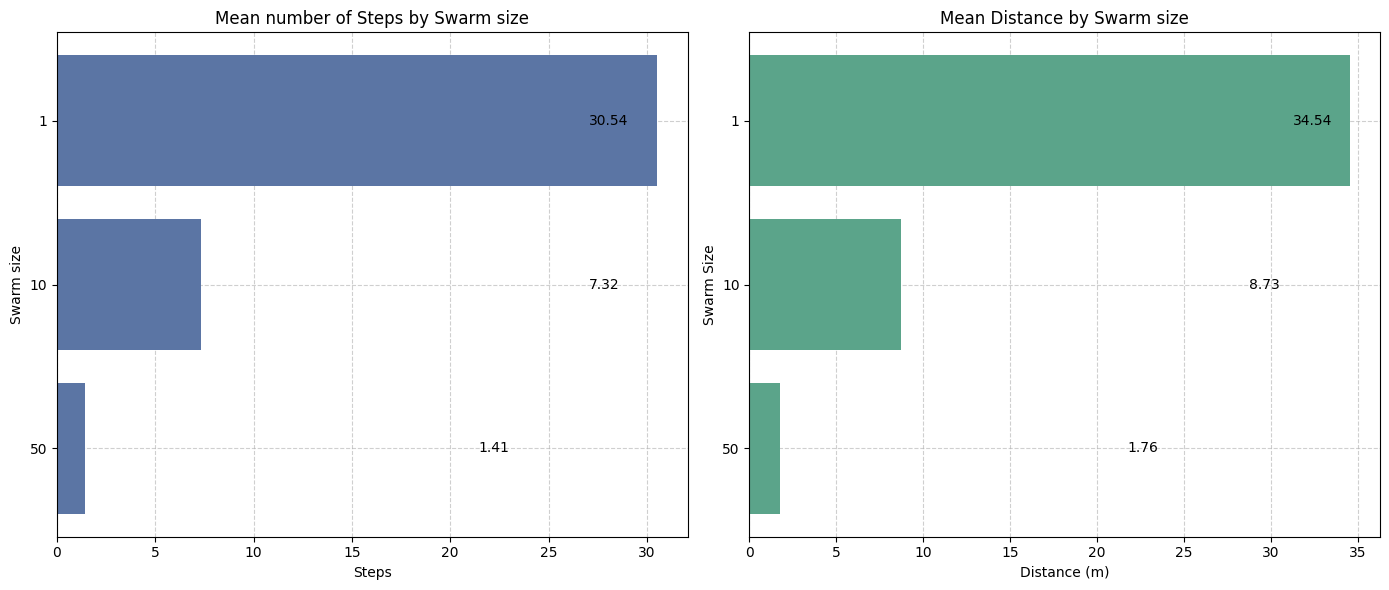

In [12]:
# Histograma
# Se agrupa cada estrategia y se calcula el promedio de los steps y la distancia
mean_steps = successful_df_exp1_1.groupby('Number of Agents')['Steps'].mean().sort_values()
mean_distance = successful_df_exp1_1.groupby('Number of Agents')['Distance'].mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico de barras horizontales para Steps
axes[0].set_axisbelow(True)
axes[0].grid(True, linestyle="--", alpha=0.6)
bars_steps = axes[0].barh(mean_steps.index, mean_steps.values, color='#5B75A4')
axes[0].set_title('Mean number of Steps by Swarm size')
axes[0].set_xlabel('Steps')
axes[0].set_ylabel('Swarm size')

# Se añaden las etiquetas a las barras de Steps
x_max = axes[0].get_xlim()[1]  # Máximo valor del eje X
for bar in bars_steps:
    axes[0].text(min(bar.get_width() + 20, x_max - 5), bar.get_y() + bar.get_height() / 2,
                 f'{bar.get_width():.2f}', va='center', ha='left', color='black')

# Gráfico de barras horizontales para Distance
axes[1].set_axisbelow(True)
axes[1].grid(True, linestyle="--", alpha=0.6)
bars_distance = axes[1].barh(mean_distance.index, mean_distance.values, color='#5BA48A')
axes[1].set_title('Mean Distance by Swarm size')
axes[1].set_xlabel('Distance (m)')
axes[1].set_ylabel('Swarm Size')

# Se añaden las etiquetas a las barras de Distance
x_max = axes[1].get_xlim()[1]  # Máximo valor del eje X
for bar in bars_distance:
    axes[1].text(min(bar.get_width() + 20, x_max -5), bar.get_y() + bar.get_height() / 2,
                 f'{bar.get_width():.2f}', va='center', ha='left', color='black')

plt.tight_layout()
plt.savefig("graficas-enjambre/exp-1-1-peq/histo-pasos-1-1-peq.pdf")
plt.show()

Otra manera de verlo es el número de Steps con respecto al número de ejecuciones.

In [13]:
execution_data = []

for swarm_size, group in combined_data_exp1_1.groupby("Number of Agents"):
    num_executions = len(group)
    executions = list(range(1, num_executions + 1))


    execution_data.extend(zip(executions, [swarm_size] * num_executions))


execution_df = pd.DataFrame(execution_data, columns=["Execution", "Number of Agents"])

# print(execution_df)

In [14]:
global_xmin = combined_data_exp1_1["Steps"].min()
global_xmax = combined_data_exp1_1["Steps"].max()
global_ymax = combined_data_exp1_1.groupby("Number of Agents")["Steps"].value_counts().max()


fig_hist = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=[f'Distribution of Steps for {s} agents' for s in swarms[:3]],
    vertical_spacing=0.1,
    horizontal_spacing=0.1,
)

for idx, swarm_size in enumerate(swarms[:3]):
    row = idx // 2 + 1
    col = idx % 2 + 1

    swarm_data = combined_data_exp1_1[combined_data_exp1_1['Number of Agents'] == swarm_size]['Steps'].dropna()

    # Histograma
    fig_hist.add_trace(
        go.Histogram(
            x=swarm_data,
            name=swarm_size,
            nbinsx=200,
            marker=dict(color='#5BA48A'),
            opacity=1
        ),
        row=row,
        col=col
    )

    if len(swarm_data) > 1:
        kde = gaussian_kde(swarm_data)
        x_vals = np.linspace(global_xmin, global_xmax, 500)
        y_vals = kde(x_vals)
        y_vals = y_vals * len(swarm_data) * (global_xmax - global_xmin) / 200

        fig_hist.add_trace(
            go.Scatter(
                x=x_vals,
                y=y_vals,
                mode='lines',
                line=dict(color='#A45B75', width=1.5),
                name=f'KDE - {swarm_size}',
            ),
            row=row,
            col=col
        )

    fig_hist.update_xaxes(title_text="Number of Steps", row=row, col=col, range=[global_xmin, global_xmax])
    fig_hist.update_yaxes(title_text="Frequency", row=row, col=col, range=[0, global_ymax])

fig_hist.update_layout(
    showlegend=False,
    title_text="Steps Distribution by Swarm size",
    height=1000,
    width=1000,
    bargap=0.1,
)

fig_hist.write_image("graficas-enjambre/exp-1-1-peq/histo-dist-1-1-peq.pdf")
fig_hist.show()

In [15]:
# Histograma combinado para todas las estrategias
fig_combined = go.Figure()

for idx, swarm_size in enumerate(swarms[:3]):
    swarm_data = combined_data_exp1_1[combined_data_exp1_1['Number of Agents'] == swarm_size]['Steps'].dropna()

    # Histograma para cada estrategia
    fig_combined.add_trace(
        go.Histogram(
            x=swarm_data,
            name=swarm_size,
            nbinsx=200,
            opacity=0.8,
            marker=dict(color=swarm_colors[swarm_size]),
        )
    )

fig_combined.update_layout(
    title_text="Combined Steps Distribution for all swarm sizes",
    xaxis_title="Number of Steps",
    yaxis_title="Frequency",
    barmode='overlay',
    height=600,
    width=800,
    xaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
    ),
    plot_bgcolor='white',
)


fig_combined.write_image("graficas-enjambre/exp-1-1-peq/histo-dist-comb-1-1-peq.pdf")
fig_combined.show()


#### Cumulativce Distribution Funcion
La CDF permite visualizar cómo se distribuyen los datos de los 'steps' a medida que se acumulan más valores:

In [16]:
# Figura de Cumulative Distribution Function
fig_cumulative = go.Figure()

for idx, swarm_size in enumerate(swarms[:3]):
    swarm_data = combined_data_exp1_1[combined_data_exp1_1['Number of Agents'] == swarm_size]['Steps'].dropna()

    # Calcular la distribución acumulada
    sorted_data = np.sort(swarm_data)
    y_vals = np.arange(1, len(sorted_data) + 1) / len(sorted_data)  # Normalización a 0-1
    color = swarm_colors[swarm_size]  # Color
    line_style = swarm_lines[swarm_size] # Tipo de línea

    # Curva
    fig_cumulative.add_trace(
        go.Scatter(
            x=sorted_data,
            y=y_vals,
            mode='lines',
            name=swarm_size,
            line=dict(color=color, dash=line_style),
            opacity=0.8
        )
    )

fig_cumulative.update_layout(
    title_text="Cumulative Distribution of Steps for all swarm sizes",
    xaxis_title="Number of Steps",
    yaxis_title="Cumulative Frequency",
    height=600,
    width=800,
    xaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
    ),
    plot_bgcolor='white',
)

fig_cumulative.write_image("graficas-enjambre/exp-1-1-peq/cdf-1-1-peq.pdf")
fig_cumulative.show()

#### Boxplot
Por último un para ayudar a entender la distribución con más información (rango, percentiles, outliers, etc.).

In [17]:
point_color = '#BFACB5'


fig_box = px.box(successful_df_exp1_1,
                 x='Number of Agents',
                 y='Steps',
                 title='Steps Distribution (Box Plot)',
                 labels={'Steps': 'Number of Steps'},
                 height=500,
                 category_orders={'Number of Agents': swarms},
                 color='Number of Agents',
                 color_discrete_map=swarm_colors
)

# Añadir los puntos de dispersión para todos los casos de prueba (incluyendo los fallidos)
for swarm_size in swarms: #combined_data['Number of Agents'].unique():
    swarm_data = combined_data_exp1_1[combined_data_exp1_1['Number of Agents'] == swarm_size]


    fig_box.add_trace(
        go.Scatter(
            x=[swarm_size] * len(swarm_data),
            y=swarm_data['Steps'],
            mode='markers',
            marker=dict(
                color=point_color,
                opacity=0.2,
                size=5
            ),
            showlegend=False,
        )
    )

fig_box.update_layout(
    height=500,
    title='Steps Distribution (Box Plot with All Attempts)',
    yaxis_title='Number of Steps',
)

fig_box.write_image("graficas-enjambre/exp-1-1-peq/boxplot-1-1-peq.pdf")
fig_box.show()

### Tiempo para encontrar al objetivo
Muy parecido a la distancia  
Distancia recorrida $\propto$ Tiempo que tarda  
Ya que en cada unidad de tiempo da un paso  

### Tasa de éxito
Separado por estrategia

In [18]:
# success_rate = combined_data.groupby("Number of Agents")["Found"].mean().map(lambda x: x*100, na_action="ignore").reset_index()
success_stats = combined_data_exp1_1.groupby("Number of Agents")["Found"].agg([
    ("num_attempts", "count"), # Aunque si fue bien todos deberían tener la misma cantidad (solo para chequear)
    ("successes", "sum"),
    ("success_rate", lambda x: (100 * x.sum() / len(x)))
]).round(2).sort_values(by="Number of Agents", axis=0 ,key=lambda col: col.astype("int32"))

success_stats

,num_attempts,successes,success_rate
Number of Agents,,,
1,1000,1000,100.0
10,1000,1000,100.0
50,1000,1000,100.0


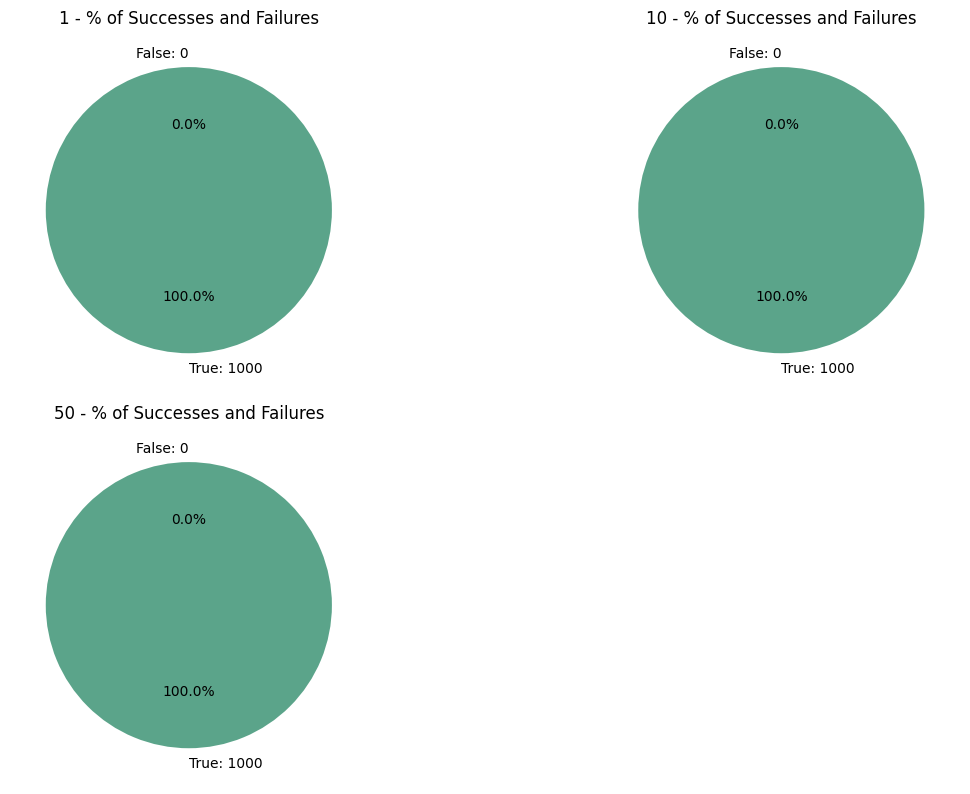

In [19]:
# Gráficas con los porcentajes de misiones que encuentran el objetivo (exito)
fig, axes = plt.subplots(3, 2, figsize=(12,12))
axes = axes.flatten()

for i, swarm_size in enumerate(swarms[:3]):
    ax = axes[i]

    swarm_data = combined_data_exp1_1[combined_data_exp1_1["Number of Agents"] == swarm_size]

    found_counts = swarm_data["Found"].value_counts()
    values = [found_counts.get(True, 0), found_counts.get(False, 0)]
    labels = [f'True: {values[0]}', f'False: {values[1]}']

    ax.pie(values, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors_found.values())
    ax.set_title(f'{swarm_size} - % of Successes and Failures')


# ax_total = axes[len(swarms)]
# found_counts_total = combined_data_exp1_1["Found"].value_counts()
# values_total = [found_counts_total.get(True, 0), found_counts_total.get(False, 0)]
# labels_total = [f'True: {values_total[0]}', f'False: {values_total[1]}']

# ax_total.pie(values_total, labels=labels_total, autopct='%1.1f%%', startangle=90, colors=colors_found.values())
# ax_total.set_title('Total - % of Successes and Failures', fontweight='bold')

# Quitar el gráfico 4,5 y 6 de la malla
for j in range(len(swarms[:3]), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("graficas-enjambre/exp-1-1-peq/pie-exito-1-1-peq.pdf")
plt.show()

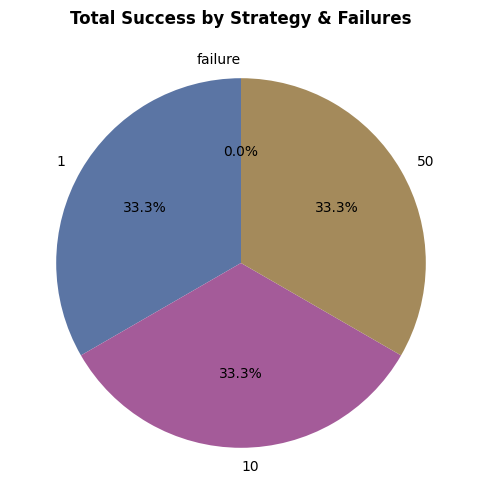

In [20]:
success_counts = combined_data_exp1_1[combined_data_exp1_1["Found"] == True]["Number of Agents"].value_counts()

failure_count = (combined_data_exp1_1["Found"] == False).sum()

labels = list(swarm_colors.keys())
sizes = [success_counts.get(swarm_size, 0) for swarm_size in swarms[:3]] + [failure_count]
colors = list(swarm_colors.values())
fig, ax = plt.subplots(figsize=(6, 6))

ax.pie(sizes, labels=labels[:3]+labels[4:], autopct='%1.1f%%', startangle=90, colors=colors)
ax.set_title("Total Success by Strategy & Failures", fontweight="bold")

plt.savefig("graficas-enjambre/exp-1-1-peq/pie-exito-total-1-1-peq.pdf")
plt.show()

# Caso de estudio 1: Escenario 2 (`mediano`)
- indicios: 1, posición fija
- agentes: {1,10,50,100}, posición aleatoria desde el borde
- escenario: mediano


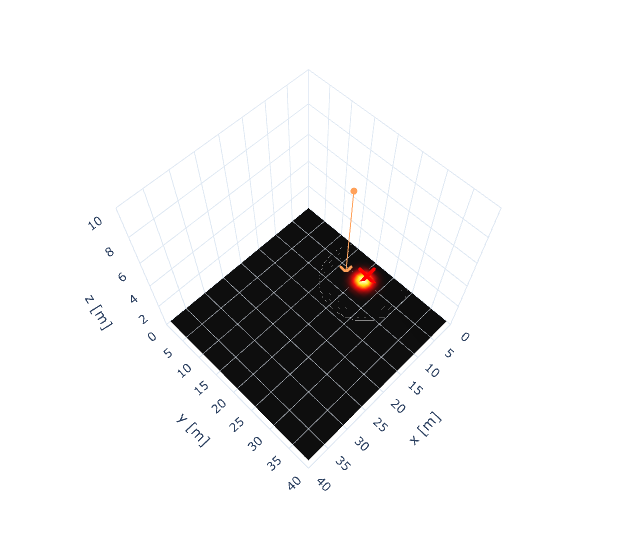

## Cargar los archivos

In [21]:
# Abrir la carpeta para el analisis (tarda ~1 min/1000 archivos)
conf = "mediano-indicios-1-agentes-n"
testing_path = f"./resultados/{conf}/"

params = json.load(open(f"./pruebas/{conf}.json"))

combined_data_exp1_2 = process_all(testing_path)

successful_df_exp1_2 = combined_data_exp1_2[combined_data_exp1_2["Found"]]

In [22]:
print(combined_data_exp1_2)

       Strategy Number of Agents  Steps  Steps finder  Distance  \
0     ldfs-heur              100    4.0           4.0    5.6569   
1     ldfs-heur              100    8.0           8.0   11.3137   
2     ldfs-heur              100    5.0           5.0    5.8284   
3     ldfs-heur              100    4.0           4.0    5.6569   
4     ldfs-heur              100    9.0           9.0   12.3137   
...         ...              ...    ...           ...       ...   
3995  ldfs-heur                1   10.0          10.0   12.4853   
3996  ldfs-heur                1   12.0          12.0   13.6569   
3997  ldfs-heur                1   32.0          32.0   36.6274   
3998  ldfs-heur                1   16.0          16.0   19.7279   
3999  ldfs-heur                1   22.0          22.0   25.3848   

      Mean displacement  Found  
0              3.998848   True  
1              5.882527   True  
2              4.738343   True  
3              4.112966   True  
4              6.710328   True

## Analisis de resultados
Métricas agregadas  
- Tiempo
  - analisis de distribución
  - estadisticas descriptivas(µ, var...)
  - gráficos (dispersión, histograma, boxplot)

- Distancia:
  - analisis de distribución
  - estadisticas descriptivas(µ, var...)
  - gráficos (dispersión, histograma, boxplot)

- Tasa de éxito
- Tasa de error
  - estadisticas descriptivas

### Distancia recorrida

In [23]:
# Descripción general de los datos
combined_data_exp1_2.groupby("Number of Agents")["Steps"].describe().sort_values(by="Number of Agents", axis=0, key=lambda col: col.astype("int32"))

,count,mean,std,min,25%,50%,75%,max
Number of Agents,,,,,,,,
1,1000.0,19.575,6.475207,3.0,15.0,20.0,24.0,50.0
10,1000.0,11.002,3.404936,2.0,9.0,11.0,13.0,24.0
50,1000.0,7.574,2.518107,2.0,6.0,8.0,9.0,16.0
100,1000.0,6.751,2.486601,2.0,5.0,7.0,8.0,16.0


In [24]:
# La cantidad de pasos que más se repite (moda)
combined_data_exp1_2.groupby("Number of Agents")["Steps"].agg(lambda x: x.mode().iloc[0]).sort_index(axis=0, key=lambda col: col.astype("int32"))

,Steps
Number of Agents,
1,20.0
10,11.0
50,8.0
100,8.0


In [25]:
# Distancia
combined_data_exp1_2.groupby("Number of Agents")["Distance"].describe().sort_values(by="Number of Agents", axis=0, key=lambda col: col.astype("int32"))

,count,mean,std,min,25%,50%,75%,max
Number of Agents,,,,,,,,
1,1000.0,23.936804,7.625976,4.2426,18.7279,23.89950,29.08885,56.6985
10,1000.0,14.158979,4.562188,2.8284,11.2426,13.94975,17.14210,29.6274
50,1000.0,10.001039,3.440950,2.4142,7.0711,9.89950,12.31370,22.6274
100,1000.0,8.996226,3.325212,2.0000,6.6569,8.65690,11.31370,20.9706


In [26]:
# Desplazamiento medio de los agentes en cada prueba
combined_data_exp1_2.groupby("Number of Agents")["Mean displacement"].describe().sort_values(by="Number of Agents", axis=0, key=lambda col: col.astype("int32"))

,count,mean,std,min,25%,50%,75%,max
Number of Agents,,,,,,,,
1,1000.0,22.144185,6.607930,4.123106,17.804494,22.203603,26.870058,38.288379
10,1000.0,13.189286,3.440846,2.769191,10.906057,13.448861,15.592766,21.957351
50,1000.0,7.893588,2.138333,2.392905,6.458983,8.130192,9.353692,13.945478
100,1000.0,5.390708,1.390283,2.052673,4.378788,5.448268,6.386975,9.023683


#### Histogramas

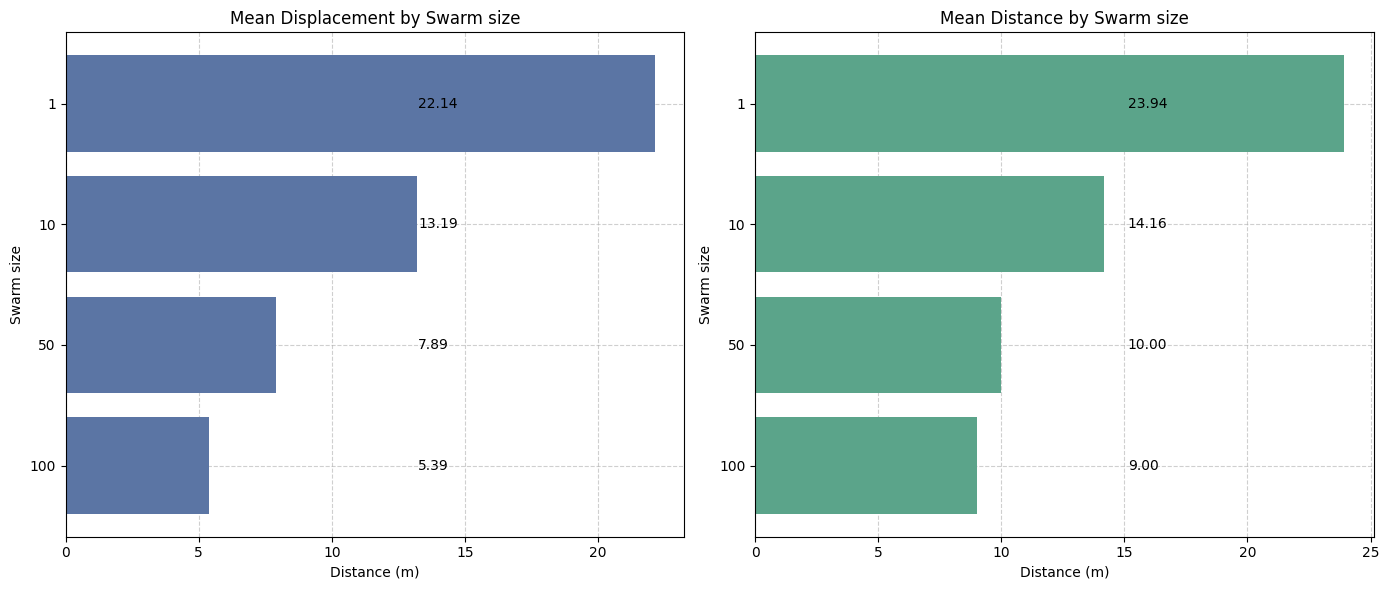

In [27]:
# Histograma
# Se agrupa cada estrategia y se calcula el promedio de los steps y la distancia
# mean_steps = successful_df_exp1_2.groupby('Number of Agents')['Steps'].mean().sort_values()
mean_steps = successful_df_exp1_2.groupby('Number of Agents')['Mean displacement'].mean().sort_values()
mean_distance = successful_df_exp1_2.groupby('Number of Agents')['Distance'].mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico de barras horizontales para Steps
axes[0].set_axisbelow(True)
axes[0].grid(True, linestyle="--", alpha=0.6)
bars_steps = axes[0].barh(mean_steps.index, mean_steps.values, color='#5B75A4')
# axes[0].set_title('Mean number of Steps by Swarm size')
axes[0].set_title('Mean Displacement by Swarm size')
# axes[0].set_xlabel('Steps')
axes[0].set_xlabel('Distance (m)')
axes[0].set_ylabel('Swarm size')

# Se añaden las etiquetas a las barras de Steps
x_max = axes[0].get_xlim()[1]  # Máximo valor del eje X
for bar in bars_steps:
    axes[0].text(min(bar.get_width() + 20, x_max - 10), bar.get_y() + bar.get_height() / 2,
                 f'{bar.get_width():.2f}', va='center', ha='left', color='black')

# Gráfico de barras horizontales para Distance
axes[1].set_axisbelow(True)
axes[1].grid(True, linestyle="--", alpha=0.6)
bars_distance = axes[1].barh(mean_distance.index, mean_distance.values, color='#5BA48A')
axes[1].set_title('Mean Distance by Swarm size')
axes[1].set_xlabel('Distance (m)')
axes[1].set_ylabel('Swarm size')

# Se añaden las etiquetas a las barras de Distance
x_max = axes[1].get_xlim()[1]  # Máximo valor del eje X
for bar in bars_distance:
    axes[1].text(min(bar.get_width() + 20, x_max -10), bar.get_y() + bar.get_height() / 2,
                 f'{bar.get_width():.2f}', va='center', ha='left', color='black')

plt.tight_layout()
plt.savefig("graficas-enjambre/exp-1-2-mediano/histo-pasos-1-2-mediano.pdf")
plt.show()

Otra manera de verlo es el número de Steps con respecto al número de ejecuciones.

In [28]:
execution_data = []

for swarm_size, group in combined_data_exp1_2.groupby("Number of Agents"):
    num_executions = len(group)
    executions = list(range(1, num_executions + 1))


    execution_data.extend(zip(executions, [swarm_size] * num_executions))


execution_df = pd.DataFrame(execution_data, columns=["Execution", "Number of Agents"])

# print(execution_df)

In [29]:
global_xmin = combined_data_exp1_2["Steps"].min()
global_xmax = combined_data_exp1_2["Steps"].max()
global_ymax = combined_data_exp1_2.groupby("Number of Agents")["Steps"].value_counts().max()


fig_hist = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=[f'Distribution of Steps for {s}' for s in swarms],
    vertical_spacing=0.1,
    horizontal_spacing=0.1,
)

for idx, swarm_size in enumerate(swarms):
    row = idx // 2 + 1
    col = idx % 2 + 1

    swarm_data = combined_data_exp1_2[combined_data_exp1_2['Number of Agents'] == swarm_size]['Steps'].dropna()

    # Histograma
    fig_hist.add_trace(
        go.Histogram(
            x=swarm_data,
            name=swarm_size,
            nbinsx=200,
            marker=dict(color='#5BA48A'),
            opacity=1
        ),
        row=row,
        col=col
    )

    if len(swarm_data) > 1:
        kde = gaussian_kde(swarm_data)
        x_vals = np.linspace(global_xmin, global_xmax, 500)
        y_vals = kde(x_vals)
        y_vals = y_vals * len(swarm_data) * (global_xmax - global_xmin) / 200

        fig_hist.add_trace(
            go.Scatter(
                x=x_vals,
                y=y_vals,
                mode='lines',
                line=dict(color='#A45B75', width=1.5),
                name=f'KDE - {swarm_size}',
            ),
            row=row,
            col=col
        )

    fig_hist.update_xaxes(title_text="Number of Steps", row=row, col=col, range=[global_xmin, global_xmax])
    fig_hist.update_yaxes(title_text="Frequency", row=row, col=col, range=[0, global_ymax])

fig_hist.update_layout(
    showlegend=False,
    title_text="Steps Distribution by Strategy",
    height=1000,
    width=1000,
    bargap=0.1,
)

fig_hist.write_image("graficas-enjambre/exp-1-2-mediano/histo-dist-1-2-mediano.pdf")
fig_hist.show()

In [30]:
# Histograma combinado para todas las estrategias
fig_combined = go.Figure()

for idx, swarm_size in enumerate(swarms):
    swarm_data = combined_data_exp1_2[combined_data_exp1_2['Number of Agents'] == swarm_size]['Steps'].dropna()

    # Histograma para cada estrategia
    fig_combined.add_trace(
        go.Histogram(
            x=swarm_data,
            name=swarm_size,
            nbinsx=200,
            opacity=0.8,
            marker=dict(color=swarm_colors[swarm_size]),
        )
    )

fig_combined.update_layout(
    title_text="Combined Steps Distribution for all swarm sizes",
    xaxis_title="Number of Steps",
    yaxis_title="Frequency",
    barmode='overlay',
    height=600,
    width=800,
    xaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
    ),
    plot_bgcolor='white',
)

fig_combined.write_image("graficas-enjambre/histo-dist-comb-1-2-mediano.pdf")
fig_combined.show()


#### Cumulativce Distribution Funcion
La CDF permite visualizar cómo se distribuyen los datos de los 'steps' a medida que se acumulan más valores:

In [31]:
# Figura de Cumulative Distribution Function
fig_cumulative = go.Figure()

for idx, swarm_size in enumerate(swarms):
    swarm_data = combined_data_exp1_2[combined_data_exp1_2['Number of Agents'] == swarm_size]['Steps'].dropna()

    # Calcular la distribución acumulada
    sorted_data = np.sort(swarm_data)
    y_vals = np.arange(1, len(sorted_data) + 1) / len(sorted_data)  # Normalización a 0-1
    color = swarm_colors[swarm_size]  # Color
    line_style = swarm_lines[swarm_size] # Tipo de línea

    # Curva
    fig_cumulative.add_trace(
        go.Scatter(
            x=sorted_data,
            y=y_vals,
            mode='lines',
            name=swarm_size,
            line=dict(color=color, dash=line_style),
            opacity=0.8
        )
    )

fig_cumulative.update_layout(
    title_text="Cumulative Distribution of Steps for all swarm sizes",
    xaxis_title="Number of Steps",
    yaxis_title="Cumulative Frequency",
    height=600,
    width=800,
    xaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
    ),
    plot_bgcolor='white',
)

fig_cumulative.write_image("graficas-enjambre/exp-1-2-mediano/cdf-1-2-mediano.pdf")
fig_cumulative.show()

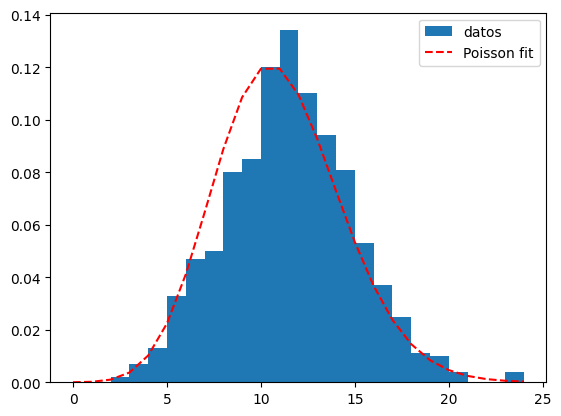

In [32]:
import scipy.stats as stats
import matplotlib.pyplot as plt

data = combined_data_exp1_2[combined_data_exp1_2['Number of Agents'] == "10"]['Steps'].dropna()
# histograma de datos
plt.hist(data, bins=range(0, int(max(data)+1)), density=True, label="datos")

# Ajuste Poisson
mu = np.mean(data)
poisson_fit = stats.poisson(mu)
plt.plot(range(0, int(max(data)+1)), poisson_fit.pmf(range(0, int(max(data)+1))), 'r--', label='Poisson fit')

plt.legend()
plt.show()


#### Boxplot
Por último un para ayudar a entender la distribución con más información (rango, percentiles, outliers, etc.).

In [33]:
point_color = '#BFACB5'


fig_box = px.box(successful_df_exp1_2,
                 x='Number of Agents',
                 y='Steps',
                 title='Steps Distribution (Box Plot)',
                 labels={'Steps': 'Number of Steps'},
                 height=500,
                 category_orders={'Number of Agents': swarms},
                 color='Number of Agents',
                 color_discrete_map=swarm_colors
)

# Añadir los puntos de dispersión para todos los casos de prueba (incluyendo los fallidos)
for swarm_size in swarms: #combined_data['Number of Agents'].unique():
    swarm_data = combined_data_exp1_2[combined_data_exp1_2['Number of Agents'] == swarm_size]


    fig_box.add_trace(
        go.Scatter(
            x=[swarm_size] * len(swarm_data),
            y=swarm_data['Steps'],
            mode='markers',
            marker=dict(
                color=point_color,
                opacity=0.2,
                size=5
            ),
            showlegend=False,
        )
    )

fig_box.update_layout(
    height=500,
    title='Steps Distribution (Box Plot with All Attempts)',
    yaxis_title='Number of Steps',
)

fig_box.write_image("graficas-enjambre/exp-1-2-mediano/boxplot-1-2-mediano.pdf")
fig_box.show()

### Tiempo para encontrar al objetivo
Muy parecido a la distancia  
Distancia recorrida $\propto$ Tiempo que tarda  
Ya que en cada unidad de tiempo da un paso  

### Tasa de éxito
Separado por estrategia

In [34]:
# success_rate = combined_data.groupby("Number of Agents")["Found"].mean().map(lambda x: x*100, na_action="ignore").reset_index()
success_stats = combined_data_exp1_2.groupby("Number of Agents")["Found"].agg([
    ("num_attempts", "count"), # Aunque si fue bien todos deberían tener la misma cantidad (solo para chequear)
    ("successes", "sum"),
    ("success_rate", lambda x: (100 * x.sum() / len(x)))
]).round(2).sort_values(by="Number of Agents", axis=0 ,key=lambda col: col.astype("int32"))
success_stats

,num_attempts,successes,success_rate
Number of Agents,,,
1,1000,1000,100.0
10,1000,1000,100.0
50,1000,1000,100.0
100,1000,1000,100.0


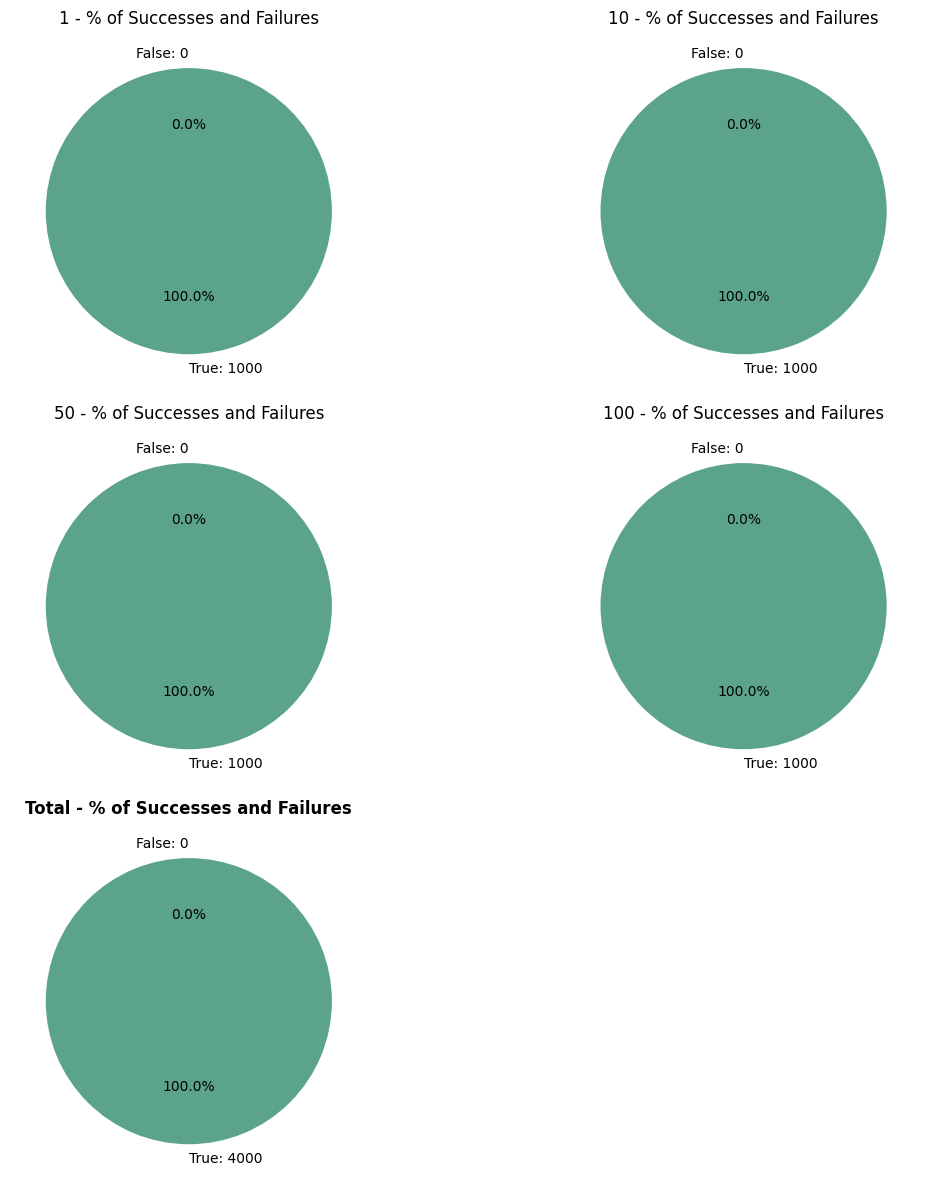

In [35]:
# Gráficas con los porcentajes de misiones que encuentran el objetivo (exito)
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()

for i, swarm_size in enumerate(swarms):
    ax = axes[i]

    swarm_data = combined_data_exp1_2[combined_data_exp1_2["Number of Agents"] == swarm_size]
    found_counts = swarm_data["Found"].value_counts()
    values = [found_counts.get(True, 0), found_counts.get(False, 0)]
    labels = [f'True: {values[0]}', f'False: {values[1]}']


    ax.pie(values, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors_found.values())
    ax.set_title(f'{swarm_size} - % of Successes and Failures')


ax_total = axes[len(swarms)]
found_counts_total = combined_data_exp1_2["Found"].value_counts()
values_total = [found_counts_total.get(True, 0), found_counts_total.get(False, 0)]
labels_total = [f'True: {values_total[0]}', f'False: {values_total[1]}']

ax_total.pie(values_total, labels=labels_total, autopct='%1.1f%%', startangle=90, colors=colors_found.values())
ax_total.set_title('Total - % of Successes and Failures', fontweight='bold')

# Sobra el 6 gráfico de la malla
for j in range(len(swarms) + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("graficas-enjambre/exp-1-2-mediano/pie-exito-1-2-mediano.pdf")
plt.show()

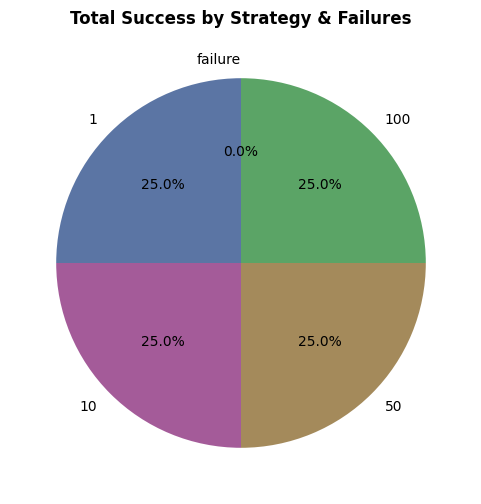

In [36]:
success_counts = combined_data_exp1_2[combined_data_exp1_2["Found"] == True]["Number of Agents"].value_counts()
failure_count = (combined_data_exp1_2["Found"] == False).sum()
labels = list(swarm_colors.keys())

sizes = [success_counts.get(swarm_size, 0) for swarm_size in swarms] + [failure_count]
colors = list(swarm_colors.values())

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
ax.set_title("Total Success by Strategy & Failures", fontweight="bold")

plt.savefig("graficas-enjambre/exp-1-2-mediano/pie-exito-total-1-2-mediano.pdf")
plt.show()

# Caso de estudio 1: Escenario 3 (`grande`)
- indicios: 1, posición fija
- agentes: {1,10,50,100}, posición aleatoria desde el borde
- escenario: grande


## Cargar los archivos

In [37]:
# Abrir la carpeta para el analisis (tarda ~1 min/1000 archivos)
conf = "grande-indicios-1-agentes-n"
testing_path = f"./resultados/{conf}/"

params = json.load(open(f"./pruebas/{conf}.json"))

combined_data_exp1_3 = process_all(testing_path)

successful_df_exp1_3 = combined_data_exp1_3[combined_data_exp1_3["Found"]]

In [38]:
print(combined_data_exp1_3)

       Strategy Number of Agents  Steps Steps finder  Distance  \
0     ldfs-heur              100   16.0         16.0   18.8995   
1     ldfs-heur              100   13.0         13.0   18.3848   
2     ldfs-heur              100   27.0         27.0   32.4558   
3     ldfs-heur              100   14.0         14.0   18.5563   
4     ldfs-heur              100   12.0         12.0   16.1421   
...         ...              ...    ...          ...       ...   
3995  ldfs-heur                1   28.0         28.0    39.598   
3996  ldfs-heur                1   72.0         72.0   86.0538   
3997  ldfs-heur                1  436.0        436.0  480.3991   
3998  ldfs-heur                1   25.0         25.0   29.5563   
3999  ldfs-heur                1   47.0         47.0   62.3259   

      Mean displacement  Found  
0             11.985547   True  
1             10.948501   True  
2             16.223307   True  
3             10.040634   True  
4             10.668512   True  
...      

## Analisis de resultados
Métricas agregadas  
- Tiempo
  - analisis de distribución
  - estadisticas descriptivas(µ, var...)
  - gráficos (dispersión, histograma, boxplot)

- Distancia:
  - analisis de distribución
  - estadisticas descriptivas(µ, var...)
  - gráficos (dispersión, histograma, boxplot)

- Tasa de éxito
- Tasa de error
  - estadisticas descriptivas

### Distancia recorrida

In [39]:
# Descripción general de los datos
combined_data_exp1_3.groupby("Number of Agents")["Steps"].describe().sort_values(by="Number of Agents", axis=0 ,key=lambda col: col.astype("int32"))

,count,mean,std,min,25%,50%,75%,max
Number of Agents,,,,,,,,
1,1000.0,87.033,151.715548,14.0,33.75,41.0,53.0,1200.0
10,1000.0,25.104,6.704785,10.0,21.00,25.0,30.0,61.0
50,1000.0,19.484,5.202000,10.0,16.00,19.0,23.0,46.0
100,1000.0,18.139,4.679699,10.0,15.00,17.0,21.0,44.0


In [40]:
# La cantidad de pasos que más se repite (moda)
combined_data_exp1_3.groupby("Number of Agents")["Steps"].agg(lambda x: x.mode().iloc[0]).sort_index(axis=0 ,key=lambda col: col.astype("int32"))

,Steps
Number of Agents,
1,35.0
10,26.0
50,16.0
100,15.0


In [41]:
# Distancia
combined_data_exp1_3.groupby("Number of Agents")["Distance"].describe().sort_values(by="Number of Agents", axis=0 ,key=lambda col: col.astype("int32"))

,count,unique,top,freq
Number of Agents,,,,
1,1000.0,780.0,46.4264,5.0
10,1000.0,448.0,22.6274,14.0
50,1000.0,299.0,21.2132,37.0
100,1000.0,244.0,21.2132,55.0


In [42]:
# Desplazamiento medio de los agentes en cada prueba
combined_data_exp1_3.groupby("Number of Agents")["Mean displacement"].describe().sort_values(by="Number of Agents", axis=0, key=lambda col: col.astype("int32"))

,count,mean,std,min,25%,50%,75%,max
Number of Agents,,,,,,,,
1,1000.0,46.144271,12.146801,7.071068,37.696154,46.443494,55.158861,75.432089
10,1000.0,23.237539,5.209029,8.707509,19.510493,23.361613,26.927464,39.118043
50,1000.0,16.454694,2.920343,9.818798,14.335403,16.296700,18.517219,26.072034
100,1000.0,13.421673,2.120244,8.562412,11.879337,13.285751,14.894794,20.814358


#### Histogramas

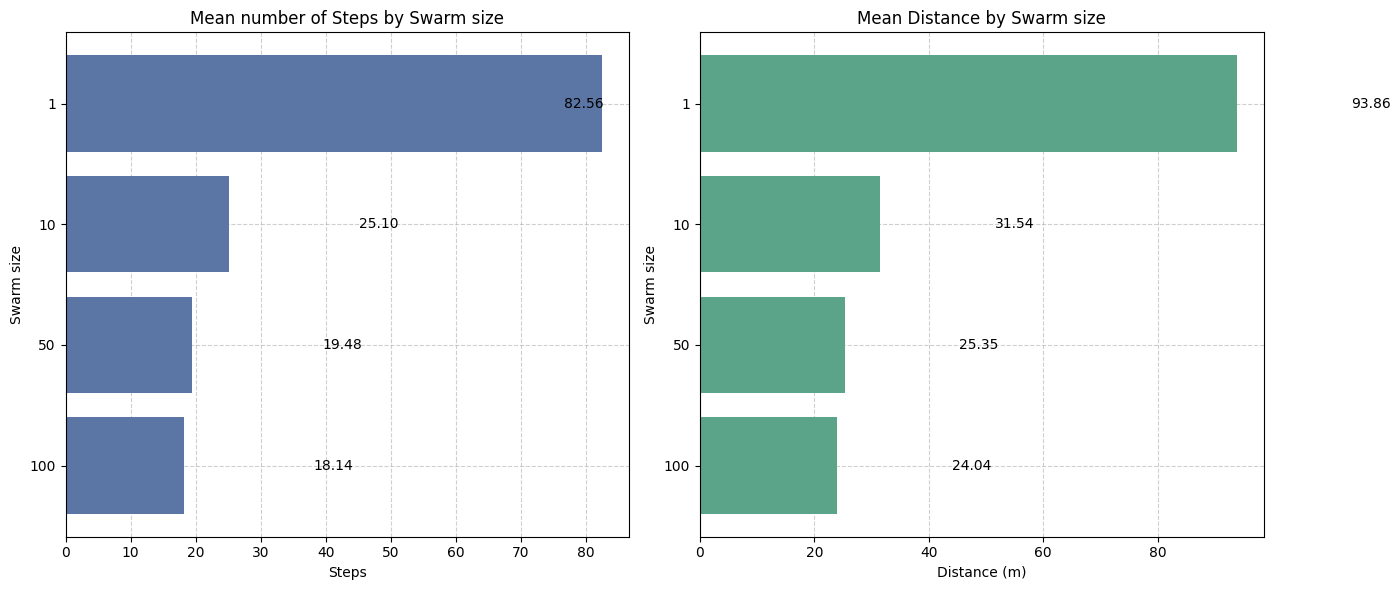

In [43]:
# Histograma
# Se agrupa cada estrategia y se calcula el promedio de los steps y la distancia
mean_steps = successful_df_exp1_3.groupby('Number of Agents')['Steps'].mean().sort_values()
mean_distance = successful_df_exp1_3.groupby('Number of Agents')['Distance'].mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico de barras horizontales para Steps
axes[0].set_axisbelow(True)
axes[0].grid(True, linestyle="--", alpha=0.6)
bars_steps = axes[0].barh(mean_steps.index, mean_steps.values, color='#5B75A4')
axes[0].set_title('Mean number of Steps by Swarm size')
axes[0].set_xlabel('Steps')
axes[0].set_ylabel('Swarm size')

# Se añaden las etiquetas a las barras de Steps
x_max = axes[0].get_xlim()[1]  # Máximo valor del eje X
for bar in bars_steps:
    axes[0].text(min(bar.get_width() + 20, x_max -10), bar.get_y() + bar.get_height() / 2,
                 f'{bar.get_width():.2f}', va='center', ha='left', color='black')

# Gráfico de barras horizontales para Distance
axes[1].set_axisbelow(True)
axes[1].grid(True, linestyle="--", alpha=0.6)
bars_distance = axes[1].barh(mean_distance.index, mean_distance.values, color='#5BA48A')
axes[1].set_title('Mean Distance by Swarm size')
axes[1].set_xlabel('Distance (m)')
axes[1].set_ylabel('Swarm size')

# Se añaden las etiquetas a las barras de Distance
x_max = axes[1].get_xlim()[1]  # Máximo valor del eje X
for bar in bars_distance:
    axes[1].text(bar.get_width() + 20, bar.get_y() + bar.get_height() / 2,
                 f'{bar.get_width():.2f}', va='center', ha='left', color='black')

plt.tight_layout()
plt.savefig("graficas-enjambre/exp-1-3-grande/histo-pasos-1-3-grande.pdf")
plt.show()

Otra manera de verlo es el número de Steps con respecto al número de ejecuciones.

In [44]:
execution_data = []

for swarm_size, group in combined_data_exp1_3.groupby("Number of Agents"):
    num_executions = len(group)
    executions = list(range(1, num_executions + 1))


    execution_data.extend(zip(executions, [swarm_size] * num_executions))


execution_df = pd.DataFrame(execution_data, columns=["Execution", "Number of Agents"])

# print(execution_df)

In [45]:
global_xmin = combined_data_exp1_3["Steps"].min()
global_xmax = combined_data_exp1_3["Steps"].max()
global_ymax = combined_data_exp1_3.groupby("Number of Agents")["Steps"].value_counts().max()


fig_hist = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=[f'Distribution of Steps for {s} agents' for s in swarms],
    vertical_spacing=0.1,
    horizontal_spacing=0.1,
)

for idx, swarm_size in enumerate(swarms):
    row = idx // 2 + 1
    col = idx % 2 + 1

    swarm_data = combined_data_exp1_3[combined_data_exp1_3['Number of Agents'] == swarm_size]['Steps'].dropna()

    # Histograma
    fig_hist.add_trace(
        go.Histogram(
            x=swarm_data,
            name=swarm_size,
            nbinsx=200,
            marker=dict(color='#5BA48A'),
            opacity=1
        ),
        row=row,
        col=col
    )

    if len(swarm_data) > 1:
        kde = gaussian_kde(swarm_data)
        x_vals = np.linspace(global_xmin, global_xmax, 500)
        y_vals = kde(x_vals)
        y_vals = y_vals * len(swarm_data) * (global_xmax - global_xmin) / 200

        fig_hist.add_trace(
            go.Scatter(
                x=x_vals,
                y=y_vals,
                mode='lines',
                line=dict(color='#A45B75', width=1.5),
                name=f'KDE - {swarm_size}',
            ),
            row=row,
            col=col
        )

    fig_hist.update_xaxes(title_text="Number of Steps", row=row, col=col, range=[global_xmin, global_xmax])
    fig_hist.update_yaxes(title_text="Frequency", row=row, col=col, range=[0, global_ymax])

fig_hist.update_layout(
    showlegend=False,
    title_text="Steps Distribution by Strategy",
    height=1000,
    width=1000,
    bargap=0.1,
)

fig_hist.write_image("graficas-enjambre/exp-1-3-grande/histo-dist-1-3-grande.pdf")
fig_hist.show()

In [46]:
# Histograma combinado para todas las estrategias
fig_combined = go.Figure()

for idx, swarm_size in enumerate(swarms):
    swarm_data = combined_data_exp1_3[combined_data_exp1_3['Number of Agents'] == swarm_size]['Steps'].dropna()

    # Histograma para cada estrategia
    fig_combined.add_trace(
        go.Histogram(
            x=swarm_data,
            name=swarm_size,
            nbinsx=200,
            opacity=0.8,
            marker=dict(color=swarm_colors[swarm_size]),
        )
    )

fig_combined.update_layout(
    title_text="Combined Steps Distribution for all swarm sizes",
    xaxis_title="Number of Steps",
    yaxis_title="Frequency",
    barmode='overlay',
    height=600,
    width=800,
    xaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
    ),
    plot_bgcolor='white',
)

fig_combined.write_image("graficas-enjambre/exp-1-3-grande/histo-dist-comb-1-3-grande.pdf")
fig_combined.show()


#### Cumulativce Distribution Funcion
La CDF permite visualizar cómo se distribuyen los datos de los 'steps' a medida que se acumulan más valores:

In [47]:
# Figura de Cumulative Distribution Function
fig_cumulative = go.Figure()

for idx, swarm_size in enumerate(swarms):
    swarm_data = combined_data_exp1_3[combined_data_exp1_3['Number of Agents'] == swarm_size]['Steps'].dropna()

    # Calcular la distribución acumulada
    sorted_data = np.sort(swarm_data)
    y_vals = np.arange(1, len(sorted_data) + 1) / len(sorted_data)  # Normalización a 0-1
    color = swarm_colors[swarm_size]  # Color
    line_style = swarm_lines[swarm_size] # Tipo de línea

    # Curva
    fig_cumulative.add_trace(
        go.Scatter(
            x=sorted_data,
            y=y_vals,
            mode='lines',
            name=swarm_size,
            line=dict(color=color, dash=line_style),
            opacity=0.8
        )
    )

fig_cumulative.update_layout(
    title_text="Cumulative Distribution of Steps for all swarm sizes",
    xaxis_title="Number of Steps",
    yaxis_title="Cumulative Frequency",
    height=600,
    width=800,
    xaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
    ),
    plot_bgcolor='white',
)

fig_cumulative.write_image("graficas-enjambre/exp-1-3-grande/cdf-1-3-grande.pdf")
fig_cumulative.show()

#### Boxplot
Por último un para ayudar a entender la distribución con más información (rango, percentiles, outliers, etc.).

In [48]:
point_color = '#BFACB5'


fig_box = px.box(successful_df_exp1_3,
                 x='Number of Agents',
                 y='Steps',
                 title='Steps Distribution (Box Plot)',
                 labels={'Steps': 'Number of Steps'},
                 height=500,
                 category_orders={'Number of Agents': swarms},
                 color='Number of Agents',
                 color_discrete_map=swarm_colors
)

# Añadir los puntos de dispersión para todos los casos de prueba (incluyendo los fallidos)
for swarm_size in swarms: #combined_data['Number of Agents'].unique():
    swarm_data = combined_data_exp1_3[combined_data_exp1_3['Number of Agents'] == swarm_size]


    fig_box.add_trace(
        go.Scatter(
            x=[swarm_size] * len(swarm_data),
            y=swarm_data['Steps'],
            mode='markers',
            marker=dict(
                color=point_color,
                opacity=0.2,
                size=5
            ),
            showlegend=False,
        )
    )

fig_box.update_layout(
    height=500,
    title='Steps Distribution (Box Plot with All Attempts)',
    yaxis_title='Number of Steps',
)

fig_box.write_image("graficas-enjambre/exp-1-3-grande/boxplot-1-3-grande.pdf")
fig_box.show()

### Tiempo para encontrar al objetivo
Muy parecido a la distancia  
Distancia recorrida $\propto$ Tiempo que tarda  
Ya que en cada unidad de tiempo da un paso  

### Tasa de éxito
Separado por estrategia

In [49]:
# success_rate = combined_data.groupby("Number of Agents")["Found"].mean().map(lambda x: x*100, na_action="ignore").reset_index()
success_stats = combined_data_exp1_3.groupby("Number of Agents")["Found"].agg([
    ("num_attempts", "count"), # Aunque si fue bien todos deberían tener la misma cantidad (solo para chequear)
    ("successes", "sum"),
    ("success_rate", lambda x: (100 * x.sum() / len(x)))
]).round(2).sort_values(by="Number of Agents", axis=0 ,key=lambda col: col.astype("int32"))
success_stats

,num_attempts,successes,success_rate
Number of Agents,,,
1,1000,996,99.6
10,1000,1000,100.0
50,1000,1000,100.0
100,1000,1000,100.0


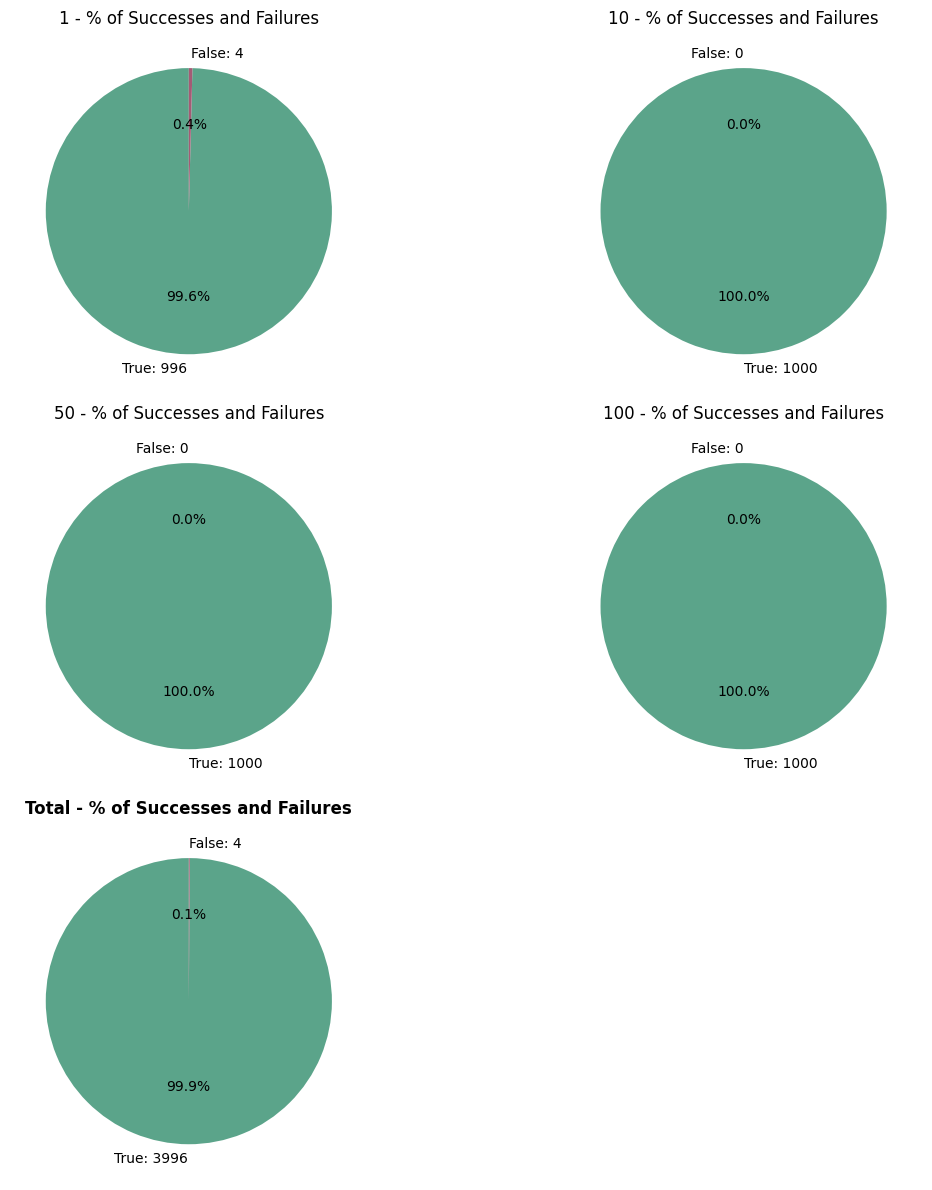

In [50]:
# Gráficas con los porcentajes de misiones que encuentran el objetivo (exito)
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()

for i, swarm_size in enumerate(swarms):
    ax = axes[i]

    swarm_data = combined_data_exp1_3[combined_data_exp1_3["Number of Agents"] == swarm_size]

    found_counts = swarm_data["Found"].value_counts()
    values = [found_counts.get(True, 0), found_counts.get(False, 0)]
    labels = [f'True: {values[0]}', f'False: {values[1]}']


    ax.pie(values, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors_found.values())
    ax.set_title(f'{swarm_size} - % of Successes and Failures')


ax_total = axes[len(swarms)]
found_counts_total = combined_data_exp1_3["Found"].value_counts()
values_total = [found_counts_total.get(True, 0), found_counts_total.get(False, 0)]
labels_total = [f'True: {values_total[0]}', f'False: {values_total[1]}']

ax_total.pie(values_total, labels=labels_total, autopct='%1.1f%%', startangle=90, colors=colors_found.values())
ax_total.set_title('Total - % of Successes and Failures', fontweight='bold')

# Sobra el 6 gráfico de la malla
for j in range(len(swarms) + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("graficas-enjambre/exp-1-3-grande/pie-exito-1-3-grande.pdf")
plt.show()

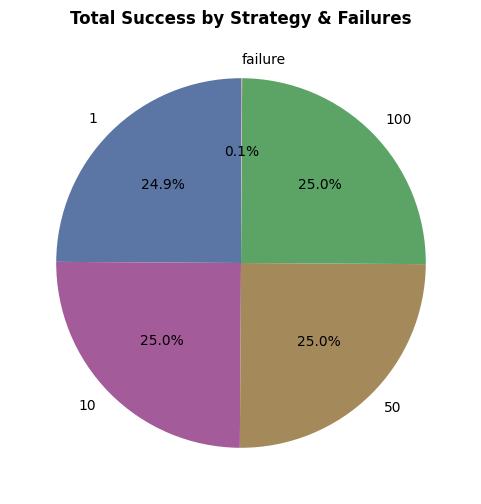

In [51]:
success_counts = combined_data_exp1_3[combined_data_exp1_3["Found"] == True]["Number of Agents"].value_counts()

failure_count = (combined_data_exp1_3["Found"] == False).sum()

labels = list(swarm_colors.keys())
sizes = [success_counts.get(swarm_size, 0) for swarm_size in swarms] + [failure_count]
colors = list(swarm_colors.values())

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
ax.set_title("Total Success by Strategy & Failures", fontweight="bold")

plt.savefig("graficas-enjambre/exp-1-3-grande/pie-exito-total-1-3-grande.pdf")
plt.show()

# Limpiar entorno

In [52]:
drive.flush_and_unmount()